In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import math

In [19]:
area = np.array([4.1, 27.6, 11.3, 38.9, 19.4, 8.7, 33.2, 15.8, 41.5, 22.9, 6.3, 29.8, 13.4, 36.1, 17.2, 44.7, 9.9, 25.3, 31.6, 12.1, 40.2, 18.6, 7.5, 34.8, 21.7, 10.4, 37.3, 16.5, 42.9, 23.8, 5.2, 28.4, 14.7, 39.6, 20.3, 45.8, 11.9, 26.7, 32.5, 8.1, 43.4, 24.6, 35.7, 30.1, 13.8])
wind_speed = np.array([31.2, 7.4, 45.8, 18.6, 3.9, 52.1, 26.3, 39.7, 11.2, 48.5, 22.8, 5.1, 35.4, 43.2, 14.7, 29.6, 8.3, 50.9, 17.1, 37.8, 24.5, 2.6, 41.3, 12.9, 46.7, 33.1, 20.4, 6.8, 28.2, 15.3, 44.6, 38.4, 25.7, 9.6, 53.2, 21.1, 30.5, 4.3, 47.9, 16.8, 36.2, 13.5, 42.8, 19.9, 27.4])
x_train = np.array([area, wind_speed])
x_train = x_train.T
y_train = np.array([21.4, 55.9, 122.6, 194.3, 27.3, 130.8, 267.1, 168.2, 122.9, 348.7, 33.2, 55.2, 148.9, 447.6, 82.0, 486.5, 24.9, 425.4, 200.7, 129.6, 383.5, 22.4, 90.6, 187.4, 372.5, 122.8, 292.9, 45.5, 507.6, 156.6, 51.1, 448.8, 156.2, 129.9, 424.4, 429.3, 138.6, 39.6, 553.9, 44.2, 502.5, 129.3, 505.6, 245.1, 149.8])

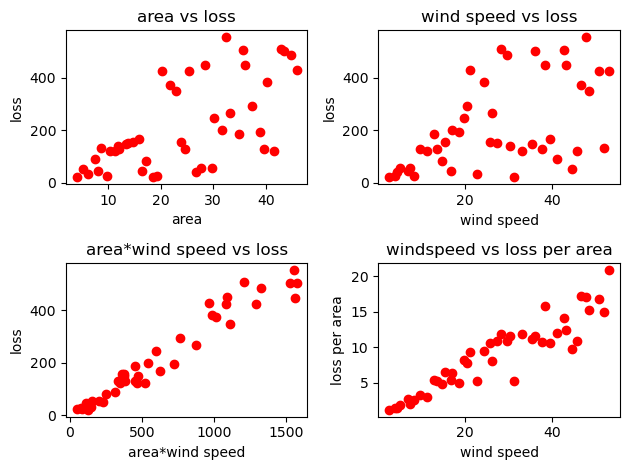

In [200]:
fig, ax = plt.subplots(2, 2)

ax[0, 0].scatter(area, y_train, marker = "o", color = "r")
ax[0, 0].set_title("area vs loss")
ax[0, 0].set_xlabel("area")
ax[0, 0].set_ylabel("loss")

ax[0, 1].scatter(wind_speed, y_train, marker = "o", color = "r")
ax[0, 1].set_title("wind speed vs loss")
ax[0, 1].set_xlabel("wind speed")
ax[0, 1].set_ylabel("loss")

ax[1, 0].scatter(area*wind_speed, y_train, marker = "o", color = "r")
ax[1, 0].set_title("area*wind speed vs loss")
ax[1, 0].set_xlabel("area*wind speed")
ax[1, 0].set_ylabel("loss")

ax[1, 1].scatter(wind_speed, y_train/area, marker = "o", color = "r")
ax[1, 1].set_title("windspeed vs loss per area")
ax[1, 1].set_xlabel("wind speed")
ax[1, 1].set_ylabel("loss per area")

plt.tight_layout()
plt.show()

# based on the above data i can say the best new feature would be area*wind speed

In [201]:
x_new_train = np.array([area, wind_speed, area*wind_speed, area*(wind_speed**2)])
x_new_train = x_new_train.T
x_new_train.shape

(45, 4)

In [202]:
def predict(x, w, b):
    fx = x @ w + b
    return fx

In [203]:
def compute_cost(x, y, w, b):
    
    m = x.shape[0]
    cost = (((x @ w + b) - y) ** 2).sum()
    cost /= 2*m

    return cost

In [204]:
def compute_gradient(x, y, w, b):

    m = x.shape[0]

    err = ((x @ w + b) - y)
    dj_dw = (err @ x)
    dj_db = err.sum()

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [205]:
def gradient_descent(x, y, alpha, iterations, threshold, w_init, b_init):
    w = w_init
    b = b_init

    j_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        j_history.append(compute_cost(x, y, w, b))

        if i % math.ceil(iterations / 10) == 0:
            print(f"Iteration: {i}, cost: {j_history[-1]}, w: {w}, b: {b}")

        if np.all(abs(dj_dw) < threshold) and abs(dj_db) < threshold:
            print(f"Iteration: {i}, cost: {j_history[-1]}, w: {w}, b: {b}")
            break

    return j_history, w, b
    

In [206]:
def z_feature_scaling(x):
    mean = x.mean(axis = 0)
    sigma = x.std(axis = 0)

    x = (x - mean)/sigma

    return x, sigma, mean

In [207]:
x_scaled = np.zeros(45*4)
x_scaled.reshape(45, 4)
x_scaled, sigma, mean = z_feature_scaling(x_new_train)
x_scaled.shape

(45, 4)

In [213]:
alpha = np.array([0.3])
w_init = np.array([0, 0, 0, 0])
print(f"w_init: {w_init.shape}, x_scaled: {x_scaled.shape}")
b_init = 0
iterations = 10000
threshold = 0.03

cost_history = []
for i in range(alpha.shape[0]):
    print(f"Learning rate: {alpha[i]}")
    cost, w_final, b_final = gradient_descent(x_scaled, y_train, alpha[i], iterations, threshold, w_init, b_init)
    cost_history.append(cost)



w_init: (4,), x_scaled: (45, 4)
Learning rate: 0.3
Iteration: 0, cost: 12820.266568324325, w: [32.01253671 26.64808589 48.19406196 43.47354364], b: 64.15533333333333
Iteration: 913, cost: 592.898818774168, w: [ -6.17135362  -8.23700085 200.58238852 -33.49186423], b: 213.85111111111107


In [215]:
prediction = predict(x_scaled, w_final, b_final)

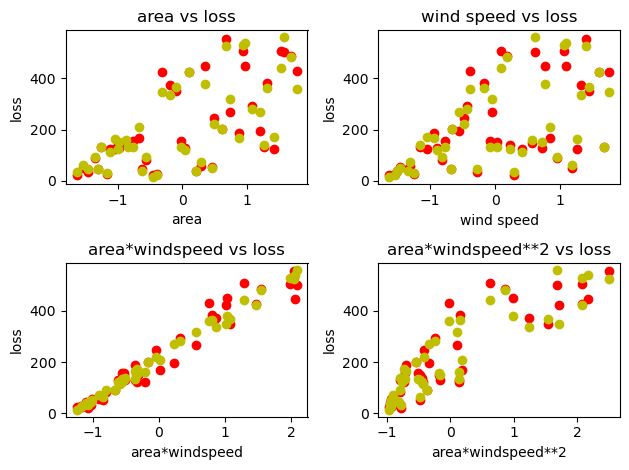

In [223]:
fig, ax = plt.subplots(2, 2)

ax[0, 0].scatter(x_scaled[:, 0], y_train, color = "r", marker="o")
ax[0, 0].scatter(x_scaled[:, 0], prediction, color = "y", marker = "o")
ax[0,0].set_title("area vs loss")
ax[0, 0].set_xlabel("area")
ax[0, 0].set_ylabel("loss")

ax[0, 1].scatter(x_scaled[:, 1], y_train, color = "r", marker="o")
ax[0, 1].scatter(x_scaled[:, 1], prediction, color = "y", marker = "o")
ax[0, 1].set_title("wind speed vs loss")
ax[0, 1].set_xlabel("wind speed")
ax[0, 1].set_ylabel("loss")

ax[1, 0].scatter(x_scaled[:, 2], y_train, color = "r", marker="o")
ax[1, 0].scatter(x_scaled[:, 2], prediction, color = "y", marker = "o")
ax[1,0].set_title("area*windspeed vs loss")
ax[1, 0].set_xlabel("area*windspeed")
ax[1, 0].set_ylabel("loss")

ax[1, 1].scatter(x_scaled[:, 3], y_train, color = "r", marker="o")
ax[1, 1].scatter(x_scaled[:, 3], prediction, color = "y", marker = "o")
ax[1, 1].set_title("area*windspeed**2 vs loss")
ax[1, 1].set_xlabel("area*windspeed**2")
ax[1, 1].set_ylabel("loss")

plt.tight_layout();
plt.show()

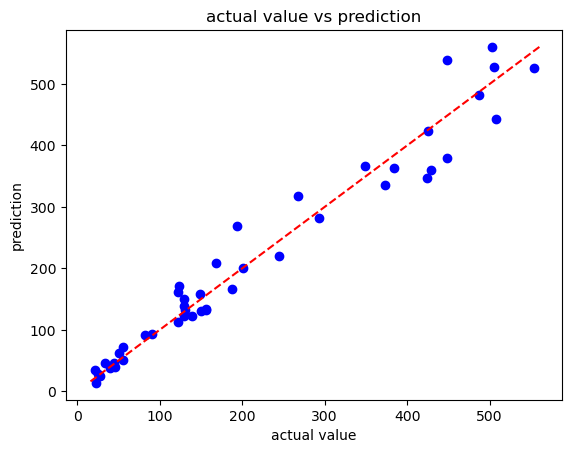

In [224]:
plt.scatter(y_train, prediction, color="b", marker="o")

hi = max(max(y_train), max(prediction))
lo = min(min(y_train), min(prediction))

plt.plot([hi, lo], [hi, lo], color = "r", linestyle='--')
plt.title("actual value vs prediction")
plt.xlabel("actual value")
plt.ylabel("prediction")

plt.show()

final predicition 

In [228]:
area1 = 18
wind_speed1 = 22
user_x = np.array([area1, wind_speed1, area1*wind_speed1, area1*(wind_speed1**2)])
user_x  = (user_x - mean)/sigma

In [232]:
final_prediction = predict(user_x, w_final, b_final)
print(f"For area: {area1}, wind_speed: {wind_speed1}, loss = {final_prediction:.2f}")

For area: 18, wind_speed: 22, loss = 141.96
